# Banking Financial Health Classification: Feature Engineering & Preprocessing

**Project:** ARB Apex Bank - Rural Banking Risk Assessment System  

---

## Objective
Transform raw banking data into model-ready features through:
1. Missing value imputation
2. Outlier detection and treatment
3. Feature engineering (interaction terms, aggregations)
4. Categorical encoding
5. Feature scaling
6. Train-test split with stratification
7. Class imbalance handling

## Preprocessing Pipeline
- Median imputation for missing values
- Outlier capping at 1st/99th percentiles
- Create interaction features between key ratios
- One-hot encode region and bank_size
- StandardScaler for numerical features
- 80-20 stratified train-test split
- SMOTE for handling 33% minority class

# Setup and Data Loading 

In [4]:
# import required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
import warnings
import joblib 
import os 

# confifurations
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
np.random.seed(42)

#plotting style 
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
# load dataset
data_path = 'data/raw/banking_data_raw.csv'
df = pd.read_csv(data_path)

print(f"Dataset Loaded: {df.shape}")
df.head()

Dataset Loaded: (2688, 35)


,bank_id,bank_name,region,bank_size,lending_style,quarter_num,year,quarter,date,total_assets,total_equity,liquid_assets,total_loans,non_performing_loans,loan_loss_provisions,current_deposits,liquidity_ratio,capital_adequacy_ratio,cash_reserve_ratio,leverage_ratio,loan_to_deposit_ratio,npl_ratio,net_income,return_on_assets,return_on_equity,net_interest_margin,operating_expenses,cost_to_income_ratio,staff_count,branches,concentration_risk,deposit_volatility,financial_health_status,consecutive_losses,risk_reasons
0,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,1,2021,Q1,2021-Q1,47.72,7.98,8.70,17.48,1.09,0.96,36.87,18.24,16.73,22.31,19.31,47.43,6.24,2.46,5.16,30.85,11.55,1.80,70.52,57.0,6.0,30.82,17.38,0,0,NaN
1,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,2,2021,Q2,2021-Q2,49.23,8.37,8.75,15.48,1.00,1.18,35.03,17.77,17.00,21.43,11.90,44.18,6.48,2.20,4.47,26.32,7.21,1.69,92.28,80.0,10.0,49.16,26.72,0,0,NaN
2,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,3,2021,Q3,2021-Q3,44.00,7.48,7.43,26.73,1.86,0.99,35.37,16.88,17.00,18.00,18.55,75.57,6.95,2.74,6.22,36.58,7.56,2.36,50.34,29.0,11.0,23.67,8.46,0,0,NaN
3,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,4,2021,Q4,2021-Q4,47.60,8.06,8.10,15.73,1.15,1.10,36.57,17.02,16.94,14.20,16.18,43.02,7.31,1.80,3.78,22.31,6.81,3.53,64.47,55.0,7.0,40.76,29.12,0,0,NaN
4,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,5,2022,Q1,2022-Q1,51.87,8.83,9.01,27.19,2.02,1.66,39.63,17.36,17.02,24.84,16.07,68.61,7.43,0.53,1.03,6.05,3.85,2.55,90.62,25.0,2.0,17.37,7.66,0,0,NaN


# Feature Selection and Preparation 


In [6]:
# Define featue groups 
# Exclude identifiers, text fields, and target variables 

exclude_features = ['bank_id', 'bank_name', 'date', 'quarter', 'risk_reasons', 
                    'financial_health_status', 'established_year']

# Categorical features to encode
categorical_features = ['region', 'bank_size', 'lending_style']

# Numerical features 
numerical_features = [col for col in df.columns 
                     if col not in exclude_features + categorical_features]

#separate target variable 
target = 'financial_health_status'

print("Feature Groups:...")
print(f"\nCategorical features ({len(categorical_features)})")
print(categorical_features)
print(f"\nNumerical features ({len(numerical_features)})")
print(numerical_features)

Feature Groups:...

Categorical features (3)
['region', 'bank_size', 'lending_style']

Numerical features (26)
['quarter_num', 'year', 'total_assets', 'total_equity', 'liquid_assets', 'total_loans', 'non_performing_loans', 'loan_loss_provisions', 'current_deposits', 'liquidity_ratio', 'capital_adequacy_ratio', 'cash_reserve_ratio', 'leverage_ratio', 'loan_to_deposit_ratio', 'npl_ratio', 'net_income', 'return_on_assets', 'return_on_equity', 'net_interest_margin', 'operating_expenses', 'cost_to_income_ratio', 'staff_count', 'branches', 'concentration_risk', 'deposit_volatility', 'consecutive_losses']


In [13]:
# create working dataframe 
X = df[categorical_features + numerical_features].copy()
y = df[target].copy()

print(f"Features matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Target distribution:..")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3)*100}")

Features matrix shape: (2688, 29)
Target vector shape: (2688,)
Target distribution:..
financial_health_status
0    1767
1     921
Name: count, dtype: int64

Class balance: financial_health_status
0    65.7
1    34.3
Name: proportion, dtype: float64


# Missing Values Analysis Imputation

Features with Missing Values:..
----------------------------------------------------------------------
             Feature  Missing_Count  Missing_Percentage
  operating_expenses            134                4.99
cost_to_income_ratio            134                4.99
         staff_count            134                4.99
            branches            134                4.99
  concentration_risk            134                4.99
  deposit_volatility            134                4.99


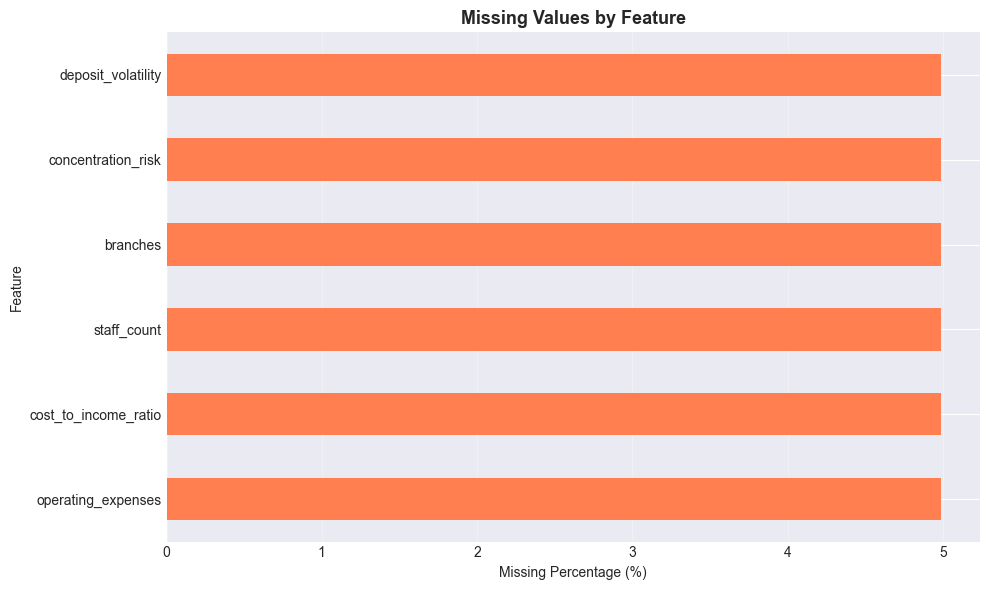

In [20]:
# Analyze missing values
missing_summary = pd.DataFrame({
    'Feature': X.columns,
    'Missing_Count': X.isnull().sum().values,
    'Missing_Percentage': (X.isnull().sum().values/len(X)*100).round(2)
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False)

if len(missing_summary) > 0:
    print("Features with Missing Values:..")
    print("-"*70)
    print(missing_summary.to_string(index=False))
    
    #visualize 
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_summary.set_index('Feature')['Missing_Percentage'].plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Missing Values by Feature', fontweight='bold', fontsize=13)
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected in the dataset")

In [22]:
# imputation -> median for numerical fetures and most frequent for categorical 
if len(missing_summary) > 0:
    numerical_with_missing = [col for col in numerical_features if X[col].isnull().sum() > 0]
    
    if len(numerical_with_missing) > 0:
        print(f"\nApplying median imputation to {len(numerical_with_missing)} numerical features")
        imputer = SimpleImputer(strategy='median')
        X[numerical_with_missing] = imputer.fit_transform(X[numerical_with_missing])
        print("Imputation complete")
        
    print(f"\nRmaining missing values: {X.isnull().sum().sum()}")
    
else:
    print(f"\nNo imputation needed - dataset has no missing values")


Applying median imputation to 6 numerical features
Imputation complete

Rmaining missing values: 0


# Oulier Detection and Treatment

In [26]:
# Detect outliers using 1st and 99th percentile 
def detect_outliers(data, features):
    """
    detect outlier beyound 1st and 99th percentiles.
    """
    outlier_summary = []
    
    for col in features:
        if col in data.columns:
            p1 = data[col].quantile(0.01)
            p99 = data[col].quantile(0.99)
            
            outliers_low = (data[col] < p1).sum()
            outliers_high = (data[col] > p99).sum()
            total_outliers = outliers_high + outliers_low
            
            if total_outliers > 0:
                outlier_summary.append({
                    'Feature': col,
                    'P1': p1,
                    'P99': p99,
                    'Outliers_Low': outliers_low,
                    'Outliers_High': outliers_high,
                    'Total_Outliers': total_outliers,
                    'Outlier_Pct': (total_outliers / len(data) * 100).round(2)
                })
    return pd.DataFrame(outlier_summary).sort_values('Total_Outliers', ascending=False)

outlier_df = detect_outliers(X, numerical_features)

if len(outlier_df) > 0:
    print("Outlier Summary (Top 15 features):")
    print("-" * 90)
    print(outlier_df.head(15).to_string(index=False))
else:
    print("No significant outliers detected")

Outlier Summary (Top 15 features):
------------------------------------------------------------------------------------------
               Feature      P1      P99  Outliers_Low  Outliers_High  Total_Outliers  Outlier_Pct
          total_assets  6.8874 888.8476            27             27              54         2.01
       liquidity_ratio  5.4461  44.3165            27             27              54         2.01
  cost_to_income_ratio 30.7774  94.3439            27             27              54         2.01
      return_on_equity  4.3574  60.7990            27             27              54         2.01
    cash_reserve_ratio  8.1787  24.8513            27             27              54         2.01
    deposit_volatility  5.3487  34.5913            27             27              54         2.01
         liquid_assets  1.2074 271.9006            27             27              54         2.01
           total_loans  2.8774 515.6242            27             27              54      

In [28]:
# Apply outlier capping (winsorization) at 1st and 99th percentiles
def cap_outliers(data, features, lower_percentile=0.01, upper_percentile=0.99):
    """
    Cap outliers at specified percentiles.
    """
    data_capped = data.copy()
    capping_info = []
    
    for col in features:
        if col in data.columns:
            lower_bound = data[col].quantile(lower_percentile)
            upper_bound = data[col].quantile(upper_percentile)
            
            # Count values that will be capped
            capped_low = (data[col] < lower_bound).sum()
            capped_high = (data[col] > upper_bound).sum()
            
            if capped_low + capped_high > 0:
                # Apply capping
                data_capped[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
                
                capping_info.append({
                    'Feature': col,
                    'Capped_Low': capped_low,
                    'Capped_High': capped_high,
                    'Total_Capped': capped_low + capped_high
                })
    
    return data_capped, pd.DataFrame(capping_info)

# Apply capping to numerical features
X_capped, capping_summary = cap_outliers(X, numerical_features)

if len(capping_summary) > 0:
    print("\nOutlier Capping Summary (Top 15):")
    print("-" * 70)
    print(capping_summary.sort_values('Total_Capped', ascending=False).head(15).to_string(index=False))
    print(f"\nTotal values capped: {capping_summary['Total_Capped'].sum():,}")
    
    # Update X with capped values
    X = X_capped
    print("\nOutlier capping applied successfully")
else:
    print("\nNo outlier capping needed")


Outlier Capping Summary (Top 15):
----------------------------------------------------------------------
               Feature  Capped_Low  Capped_High  Total_Capped
          total_assets          27           27            54
       liquidity_ratio          27           27            54
  cost_to_income_ratio          27           27            54
      return_on_equity          27           27            54
    cash_reserve_ratio          27           27            54
           total_loans          27           27            54
         liquid_assets          27           27            54
    deposit_volatility          27           27            54
  loan_loss_provisions           0           27            27
      current_deposits           0           27            27
  non_performing_loans           0           27            27
capital_adequacy_ratio           0           27            27
          total_equity           0           27            27
            net_income    

# Feature Engineering - Interaction Terms 


In [30]:
# create interaction features between key financial ratios
print("Create Interaction Features...")
print("-" * 70)

# Interaction 1: Liquidity × Capital Adequacy
X['liquidity_capital_interaction'] = X['liquidity_ratio'] * X['capital_adequacy_ratio']
print("\nliquidity_capital_interaction = liquidity_ratio × capital_adequacy_ratio -> done")

# Interaction 2: NPL × Leverage (risk amplification)
X['npl_leverage_interaction'] = X['npl_ratio'] * X['leverage_ratio']
print("\nnpl_leverage_interaction = npl_ratio × leverage_ratio -> done")

# Interaction 3: ROE × Capital Adequacy (profitability strength)
X['roe_capital_interaction'] = X['return_on_equity'] * X['capital_adequacy_ratio']
print("\nroe_capital_interaction = return_on_equity × capital_adequacy_ratio -> done")

# Interaction 4: Loan-to-Deposit × NPL (lending risk)
X['ldr_npl_interaction'] = X['loan_to_deposit_ratio'] * X['npl_ratio']
print("\nldr_npl_interaction = loan_to_deposit_ratio × npl_ratio -> done")

# Interaction 5: Cost-to-Income × Deposit Volatility (operational stress)
X['cost_volatility_interaction'] = X['cost_to_income_ratio'] * X['deposit_volatility']
print("\ncost_volatility_interaction = cost_to_income_ratio × deposit_volatility -> done")

# Aggregate features: Bank efficiency score
X['efficiency_score'] = (X['return_on_assets'] / (X['cost_to_income_ratio'] + 1)) * 100
print("\nefficiency_score =  (ROA / CIR ratio) -> done")

# Risk composite score
X['risk_composite'] = (X['npl_ratio'] * 0.4 + 
                       (100 - X['liquidity_ratio']) * 0.3 + 
                       (100 - X['capital_adequacy_ratio']) * 0.3)
print("\nrisk_composite (weighted risk score) -> done")

print(f"\nNew feature matrix shape: {X.shape}")
print(f"Added {X.shape[1] - len(categorical_features) - len(numerical_features)} interaction features")


Create Interaction Features...
----------------------------------------------------------------------

liquidity_capital_interaction = liquidity_ratio × capital_adequacy_ratio -> done

npl_leverage_interaction = npl_ratio × leverage_ratio -> done

roe_capital_interaction = return_on_equity × capital_adequacy_ratio -> done

ldr_npl_interaction = loan_to_deposit_ratio × npl_ratio -> done

cost_volatility_interaction = cost_to_income_ratio × deposit_volatility -> done

efficiency_score =  (ROA / CIR ratio) -> done

risk_composite (weighted risk score) -> done

New feature matrix shape: (2688, 36)
Added 7 interaction features


In [31]:
# Update numerical features list to include new interactions
new_features = ['liquidity_capital_interaction', 'npl_leverage_interaction', 
                'roe_capital_interaction', 'ldr_npl_interaction', 
                'cost_volatility_interaction', 'efficiency_score', 'risk_composite']

numerical_features_extended = numerical_features + new_features

print(f"\nTotal numerical features: {len(numerical_features_extended)}")
print(f"Total categorical features: {len(categorical_features)}")
print(f"Total features: {len(numerical_features_extended) + len(categorical_features)}")


Total numerical features: 33
Total categorical features: 3
Total features: 36


# Train-Test-Split

In [33]:
# Perform stratified train-test split(80-20)
X_train, X_test, y_train, y_test = train_test_split(
    
    X, y,
    test_size=0.20,
    random_state = 42,
    stratify = y
    
)

print("Train-Test Split Summary:...")
print("-"*70)
print(f"Training set: {X_train.shape[0]:} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")


print("\nTarget distribution - Training set:")
print(y_train.value_counts())
print(f"Proportion: {y_train.value_counts(normalize=True).round(3)}")

print("\nTarget distribution - Test set:")
print(y_test.value_counts())
print(f"Proportion: {y_test.value_counts(normalize=True).round(3)}")


Train-Test Split Summary:...
----------------------------------------------------------------------
Training set: 2150 samples (80.0%)
Test set: 538 samples (20.0%)

Target distribution - Training set:
financial_health_status
0    1413
1     737
Name: count, dtype: int64
Proportion: financial_health_status
0    0.657
1    0.343
Name: proportion, dtype: float64

Target distribution - Test set:
financial_health_status
0    354
1    184
Name: count, dtype: int64
Proportion: financial_health_status
0    0.658
1    0.342
Name: proportion, dtype: float64


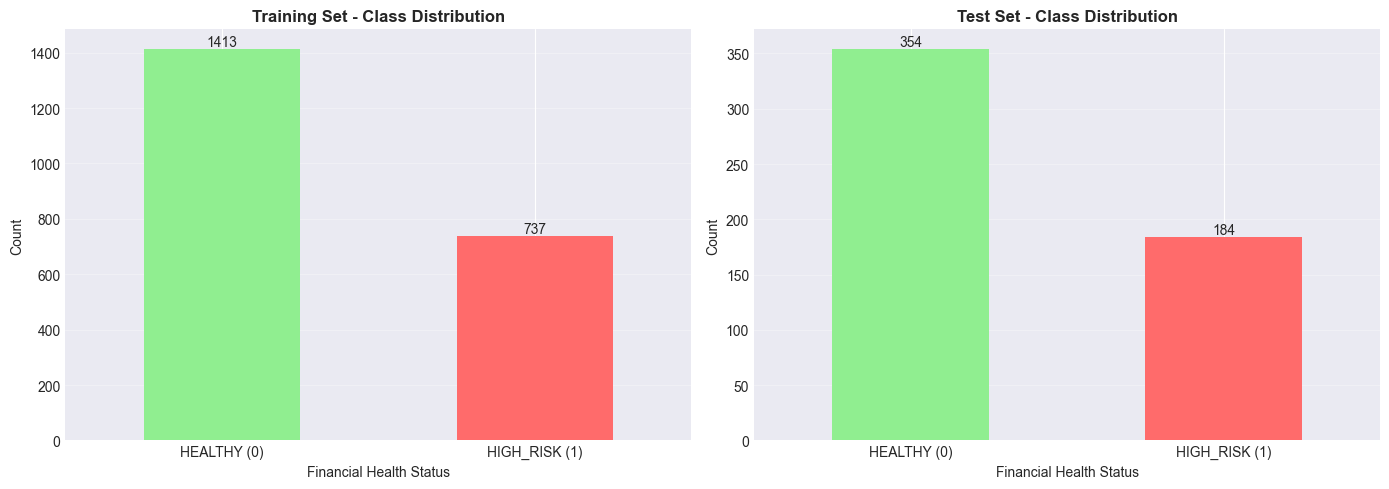

In [34]:
# Visualize class distribution in train and test sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#90EE90', '#FF6B6B'])
axes[0].set_title('Training Set - Class Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Financial Health Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['HEALTHY (0)', 'HIGH_RISK (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Test set
y_test.value_counts().plot(kind='bar', ax=axes[1], color=['#90EE90', '#FF6B6B'])
axes[1].set_title('Test Set - Class Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Financial Health Status')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['HEALTHY (0)', 'HIGH_RISK (1)'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()